# Regressao Logistica Aplicada: Predicao Pre-Voo de Satisfacao

Objetivo: prever se um passageiro ficara **satisfeito** com o voo usando apenas informacoes disponiveis **no momento da reserva**, com um modelo de **Regressao Logistica** treinado no dataset [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction) (Kaggle).

**Roteiro**
1. Configuracao do ambiente
2. Carga dos dados e definicao do problema
3. Analise exploratoria (EDA)
4. Pre-processamento
5. Treinamento e interpretacao dos coeficientes
6. Avaliacao na base de teste: curva ROC / AUC, matriz de confusao, F1-score e ponto de corte
7. Conclusao

## 1. Configuracao do Ambiente

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

/workspace/.devcontainer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga dos Dados e Definicao do Problema

O dataset ja vem dividido em **treino** e **teste**. A variavel resposta `satisfaction` e binaria:
- $Y = 1$: passageiro satisfeito (`satisfied`)
- $Y = 0$: passageiro neutro ou insatisfeito (`neutral or dissatisfied`)

In [2]:
dataset_path = Path(kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction"))
df_train_raw = pd.read_csv(dataset_path / "train.csv").drop(columns=["Unnamed: 0", "id"])
df_test_raw = pd.read_csv(dataset_path / "test.csv").drop(columns=["Unnamed: 0", "id"])

target_col = "satisfaction"
target_map = {"satisfied": 1, "neutral or dissatisfied": 0}

print(f"Treino: {df_train_raw.shape[0]:,} linhas x {df_train_raw.shape[1]} colunas")
print(f"Teste : {df_test_raw.shape[0]:,} linhas x {df_test_raw.shape[1]} colunas")
df_train_raw.head()

100%|██████████| 2.71M/2.71M [00:00<00:00, 6.30MB/s]

Extracting files...


Treino: 103,904 linhas x 23 colunas
Teste : 25,976 linhas x 23 colunas


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 3. Analise Exploratoria (EDA)

A EDA e feita **somente na base de treino**: a base de teste fica reservada para simular dados "nunca vistos" pelo modelo.

### 3.1 Estrutura e qualidade dos dados

In [3]:
resumo = pd.DataFrame({
    "Tipo": df_train_raw.dtypes.astype(str),
    "Valores Unicos": df_train_raw.nunique(),
    "Nulos": df_train_raw.isna().sum(),
})
resumo

,Tipo,Valores Unicos,Nulos
Gender,str,2,0
Customer Type,str,2,0
Age,int64,75,0
Type of Travel,str,2,0
Class,str,3,0
Flight Distance,int64,3802,0
Inflight wifi service,int64,6,0
Departure/Arrival time convenient,int64,6,0
Ease of Online booking,int64,6,0
Gate location,int64,6,0


> Apenas `Arrival Delay in Minutes` possui valores nulos (~0,3% das linhas). Como veremos a seguir, essa variavel nao sera usada no modelo, entao nao precisamos trata-la.

### 3.2 Distribuicao da variavel alvo

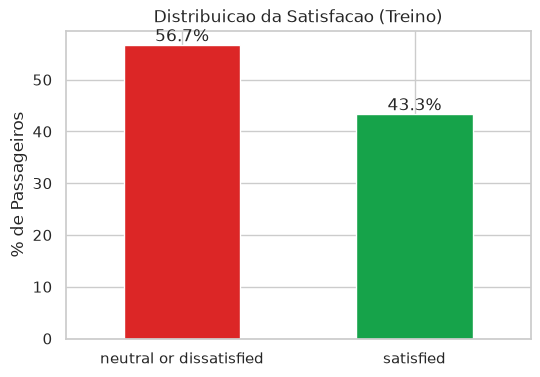

In [4]:
dist_alvo = df_train_raw[target_col].value_counts(normalize=True) * 100

ax = dist_alvo.plot(kind="bar", color=["#dc2626", "#16a34a"], figsize=(6, 4), rot=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%")
ax.set_title("Distribuicao da Satisfacao (Treino)")
ax.set_xlabel("")
ax.set_ylabel("% de Passageiros")
plt.show()

> Cerca de **43%** dos passageiros estao satisfeitos. As classes sao razoavelmente balanceadas, mas ainda assim a acuracia sozinha nao conta toda a historia. Por isso avaliaremos tambem **AUC** e **F1-score**.

### 3.3 Selecao das variaveis: a fronteira temporal (anti-leakage)

O dataset tem 22 variaveis explicativas, mas a maioria (14 notas de servico de bordo e os atrasos) **so existe depois do voo**. Usa-las criaria *data leakage*: o modelo ficaria otimo no papel, mas inutil na pratica, porque essas informacoes nao estao disponiveis no momento da decisao.

Por isso usamos apenas as 6 variaveis conhecidas **na reserva**:

In [5]:
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
num_cols = ["Age", "Flight Distance"]
features_pre_voo = cat_cols + num_cols

df_train = df_train_raw[features_pre_voo + [target_col]].copy()
df_test = df_test_raw[features_pre_voo + [target_col]].copy()
df_train["y"] = df_train[target_col].map(target_map)
df_test["y"] = df_test[target_col].map(target_map)

df_train[features_pre_voo].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0


### 3.4 Variaveis categoricas vs. satisfacao

Para cada categoria calculamos a **taxa de satisfacao**. Quanto mais a barra se afasta da media geral (linha tracejada), mais a variavel ajuda a separar as classes.

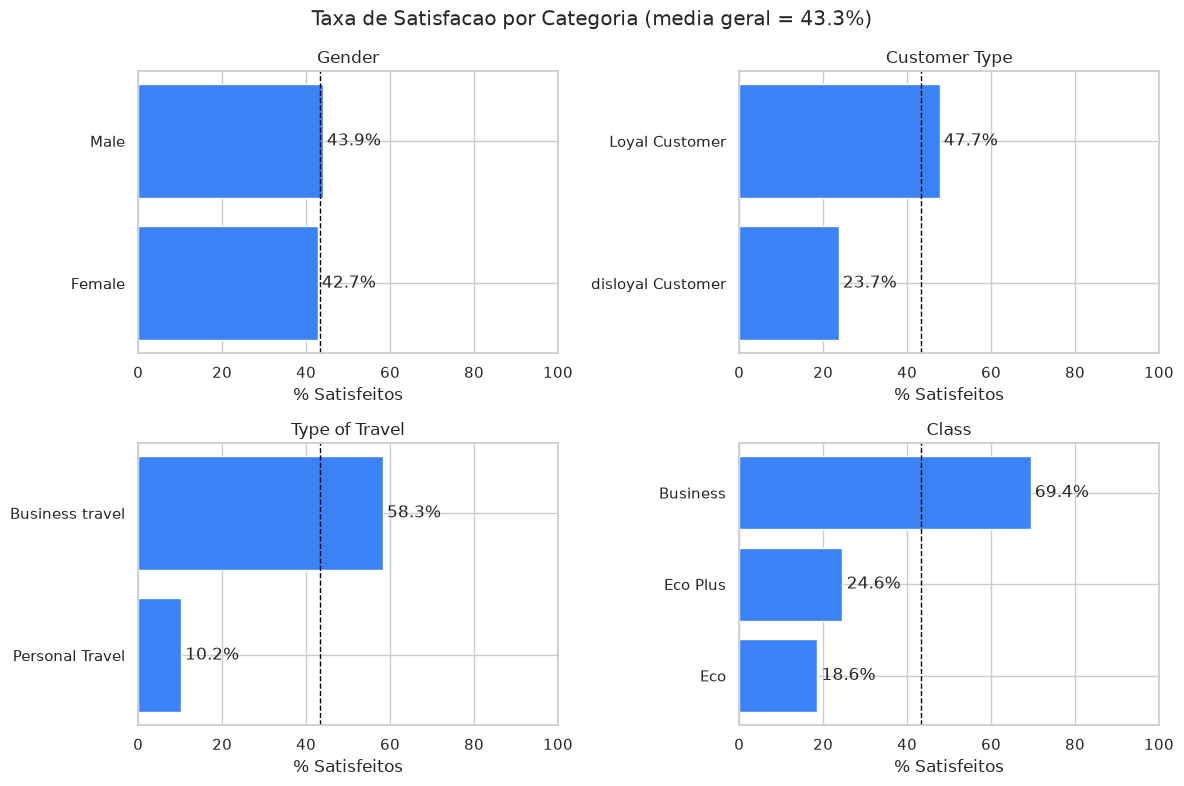

In [6]:
taxa_geral = df_train["y"].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cat_cols):
    taxa = (df_train.groupby(col)["y"].mean() * 100).sort_values()
    ax.barh(taxa.index, taxa.values, color="#3b82f6")
    ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
    ax.axvline(taxa_geral, color="black", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% Satisfeitos")
fig.suptitle(f"Taxa de Satisfacao por Categoria (media geral = {taxa_geral:.1f}%)")
plt.tight_layout()
plt.show()

> - **`Type of Travel`**: o maior separador. Viagens a negocios tem ~58% de satisfacao contra apenas ~10% em viagens pessoais.
> - **`Class`**: a classe executiva (`Business`) chega a ~69% de satisfacao, enquanto `Eco` e `Eco Plus` ficam em ~19% e ~25%.
> - **`Customer Type`**: clientes fieis (`Loyal`) tem o dobro da taxa dos ocasionais (~48% vs. ~24%).
> - **`Gender`**: praticamente nenhuma diferenca. Esperamos um coeficiente proximo de zero.

### 3.5 Variaveis numericas vs. satisfacao

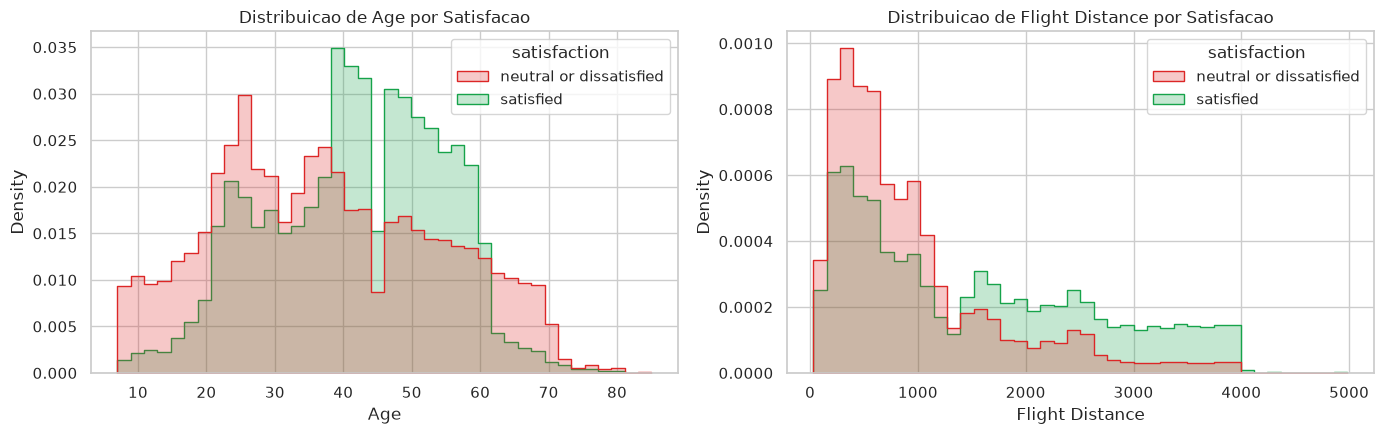

,Mediana Age,Mediana Flight Distance
satisfaction,,
neutral or dissatisfied,36.0,671.0
satisfied,43.0,1250.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df_train, x=col, hue=target_col, stat="density", common_norm=False,
        element="step", bins=40, ax=ax, palette={"satisfied": "#16a34a", "neutral or dissatisfied": "#dc2626"},
    )
    ax.set_title(f"Distribuicao de {col} por Satisfacao")
plt.tight_layout()
plt.show()

df_train.groupby(target_col)[num_cols].median().rename(columns=lambda c: f"Mediana {c}")

> Olhando isoladamente, passageiros satisfeitos parecem ser **mais velhos** (mediana 43 vs. 36 anos) e fazer **voos mais longos** (mediana ~1.250 vs. ~670 milhas). Sera que essas variaveis tem efeito proprio? A proxima analise sugere que nao necessariamente.

### 3.6 Interacao entre variaveis: o efeito de confusao

Voos longos e passageiros mais velhos aparecem com mais frequencia em **viagens de negocio na classe executiva**, justamente o grupo mais satisfeito. Vejamos a taxa de satisfacao cruzando as duas variaveis mais fortes, e a mediana de distancia/idade em cada grupo:

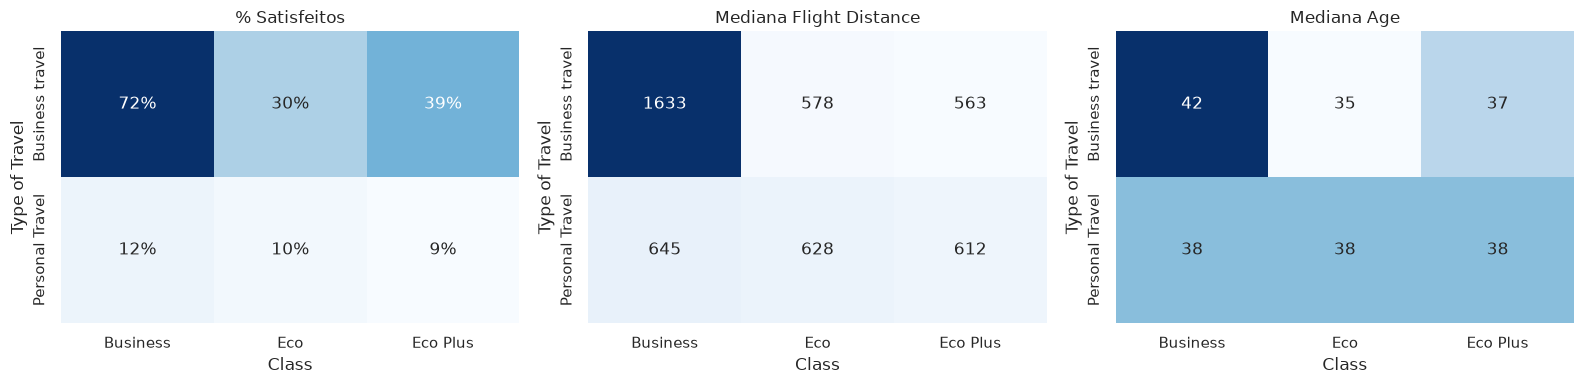

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (valor, titulo, fmt) in zip(axes, [
    ("y", "% Satisfeitos", ".0%"),
    ("Flight Distance", "Mediana Flight Distance", ".0f"),
    ("Age", "Mediana Age", ".0f"),
]):
    agg = "mean" if valor == "y" else "median"
    tabela = df_train.pivot_table(index="Type of Travel", columns="Class", values=valor, aggfunc=agg)
    sns.heatmap(tabela, annot=True, fmt=fmt, cmap="Blues", cbar=False, ax=ax)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

> A combinacao **Business travel + Business class** concentra a maior satisfacao (~72%) **e** os voos mais longos. Assim, parte da "forca" aparente de `Flight Distance` e `Age` na analise univariada vem, na verdade, do **tipo de viagem e da classe**. A regressao logistica, por estimar os efeitos **simultaneamente**, isola a contribuicao propria de cada variavel. Vamos confirmar isso nos coeficientes.

## 4. Pre-processamento

1. **One-Hot Encoding** das categoricas com `drop_first=True`: cada categoria vira uma coluna 0/1 e a primeira e removida para servir de **referencia** (evita multicolinearidade perfeita, a *dummy variable trap*).
2. **Padronizacao** (`StandardScaler`) das numericas (media 0, desvio padrao 1), para que os coeficientes fiquem na mesma escala. O ajuste (`fit`) e feito **apenas no treino** e replicado no teste.

In [9]:
y_train = df_train["y"]
y_test = df_test["y"]

X_train = pd.get_dummies(df_train[features_pre_voo], columns=cat_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(df_test[features_pre_voo], columns=cat_cols, drop_first=True, dtype=int)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Categorias de referencia: Female, Loyal Customer, Business travel, Business (classe)")
X_train.head()

Categorias de referencia: Female, Loyal Customer, Business travel, Business (classe)


,Age,Flight Distance,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,-1.745279,-0.731539,1,0,1,0,1
1,-0.951360,-0.957184,1,1,0,0,0
2,-0.885200,-0.047584,0,0,0,0,0
3,-0.951360,-0.629246,0,0,0,0,0
4,1.430397,-0.978244,1,0,0,0,0


## 5. Treinamento e Interpretacao dos Coeficientes

### Relembrando a teoria
A regressao logistica modela a probabilidade de satisfacao pela funcao **sigmoide**:

$$P(Y = 1 \mid X) = \frac{1}{1 + e^{-z}}, \qquad z = \beta_0 + \beta_1 X_1 + \dots + \beta_k X_k$$

O termo linear $z$ e o **log-odds** (logit): $\ln\left(\frac{p}{1-p}\right) = z$. Exponenciando um coeficiente obtemos o **Odds Ratio** $OR = e^{\beta}$:
- $OR > 1$: a variavel **aumenta** a chance de satisfacao;
- $OR < 1$: a variavel **reduz** a chance de satisfacao;
- $OR \approx 1$: a variavel praticamente **nao altera** a chance.

Para dummies, o OR compara a categoria com a de referencia. Para as numericas padronizadas, o OR refere-se ao aumento de **1 desvio padrao**.

In [10]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Beta (Log-Odds)": model.coef_[0],
    "Odds Ratio (e^Beta)": np.exp(model.coef_[0]),
}).sort_values("Beta (Log-Odds)")

print(f"Intercepto (Beta_0): {model.intercept_[0]:.3f}")
coef_df.round(3)

Intercepto (Beta_0): 1.223


,Feature,Beta (Log-Odds),Odds Ratio (e^Beta)
4,Type of Travel_Personal Travel,-2.263,0.104
3,Customer Type_disloyal Customer,-1.716,0.180
6,Class_Eco Plus,-1.401,0.246
5,Class_Eco,-1.261,0.283
1,Flight Distance,-0.001,0.999
0,Age,0.003,1.003
2,Gender_Male,0.020,1.021


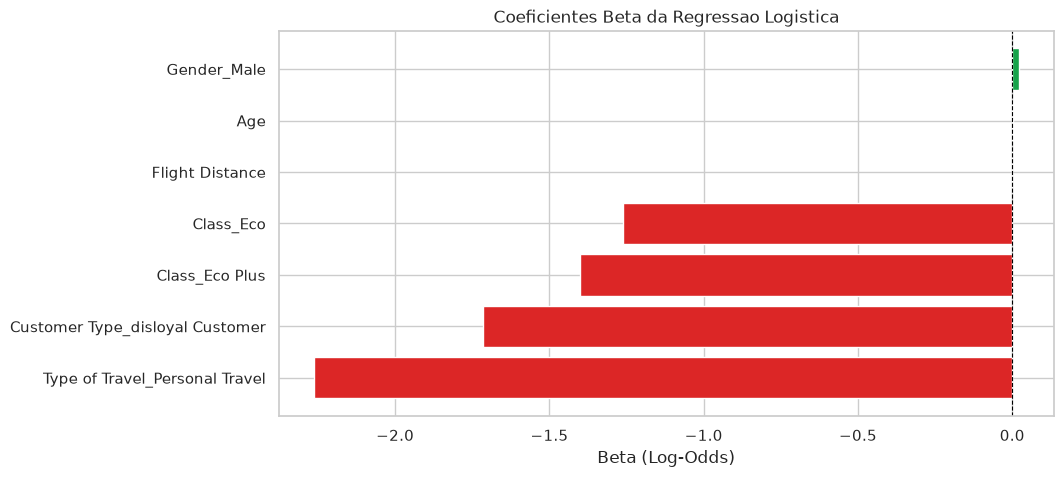

In [11]:
colors = ["#dc2626" if b < 0 else "#16a34a" for b in coef_df["Beta (Log-Odds)"]]
plt.figure(figsize=(10, 5))
plt.barh(coef_df["Feature"], coef_df["Beta (Log-Odds)"], color=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Coeficientes Beta da Regressao Logistica")
plt.xlabel("Beta (Log-Odds)")
plt.show()

> **Interpretacao**
> - **`Type of Travel_Personal Travel`** e o maior efeito negativo: mantidas as demais variaveis, viajar a lazer reduz as chances de satisfacao em cerca de **90%** em relacao a viagens de negocio ($OR \approx 0{,}10$).
> - **`Class_Eco`** e **`Class_Eco Plus`**: em comparacao a classe executiva, reduzem as chances em cerca de **72% a 75%** ($OR \approx 0{,}28$ e $0{,}25$).
> - **`Customer Type_disloyal Customer`**: clientes ocasionais tem chances cerca de **82% menores** que os fieis ($OR \approx 0{,}18$).
> - **`Gender_Male`**, **`Age`** e **`Flight Distance`**: coeficientes proximos de zero ($OR \approx 1$). Como antecipado na secao 3.6, o efeito aparente de idade e distancia era **confundido** com tipo de viagem e classe; controlando por essas variaveis, eles praticamente desaparecem.

## 6. Avaliacao na Base de Teste

O modelo retorna um **score** (probabilidade estimada de satisfacao) para cada passageiro. Avaliamos esse score de duas formas:
1. **Sem ponto de corte**: a curva ROC e o AUC medem a capacidade de *ordenar* satisfeitos acima de insatisfeitos.
2. **Com ponto de corte**: a matriz de confusao e o F1-score medem a qualidade da *decisao* binaria.

In [12]:
score_train = model.predict_proba(X_train)[:, 1]
score_test = model.predict_proba(X_test)[:, 1]

### 6.1 Curva ROC e AUC

A curva ROC mostra, para **todos os pontos de corte possiveis**, a taxa de verdadeiros positivos (**TPR** = Recall) contra a taxa de falsos positivos (**FPR**).
- **AUC = 0,5**: modelo aleatorio (diagonal).
- **AUC = 1,0**: separacao perfeita.
- Interpretacao pratica: o AUC e a probabilidade de um passageiro satisfeito, sorteado ao acaso, receber score maior que um insatisfeito sorteado ao acaso.

Comparamos treino e teste: valores proximos indicam que o modelo **nao esta sobreajustado** (*overfitting*).

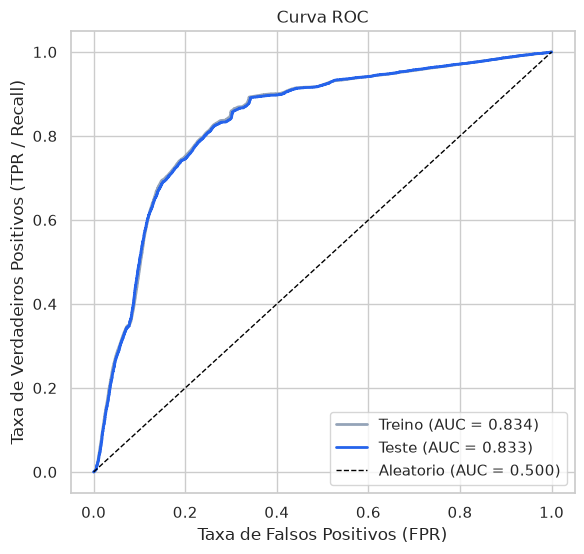

In [13]:
auc_train = roc_auc_score(y_train, score_train)
auc_test = roc_auc_score(y_test, score_test)

plt.figure(figsize=(6.5, 6))
for y_true, score, nome, auc, cor in [
    (y_train, score_train, "Treino", auc_train, "#94a3b8"),
    (y_test, score_test, "Teste", auc_test, "#2563eb"),
]:
    fpr, tpr, _ = roc_curve(y_true, score)
    plt.plot(fpr, tpr, color=cor, linewidth=2, label=f"{nome} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1, label="Aleatorio (AUC = 0.500)")
plt.title("Curva ROC")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR / Recall)")
plt.legend(loc="lower right")
plt.show()

> AUC de **~0,83** tanto no treino quanto no teste: boa capacidade de discriminacao considerando que usamos apenas 6 variaveis cadastrais, e nenhum sinal de overfitting.

### 6.2 Matriz de confusao e F1-score (ponto de corte = 0,50)

Transformamos o score em decisao: $\text{Score} \ge \text{cutoff} \Rightarrow$ Satisfeito. A partir da matriz de confusao:

| Metrica | Formula | Pergunta que responde |
|---|---|---|
| **Precision** | $\frac{TP}{TP + FP}$ | Dos que previ como satisfeitos, quantos realmente estavam? |
| **Recall** | $\frac{TP}{TP + FN}$ | Dos realmente satisfeitos, quantos eu encontrei? |
| **F1-score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Media harmonica: equilibrio entre as duas |

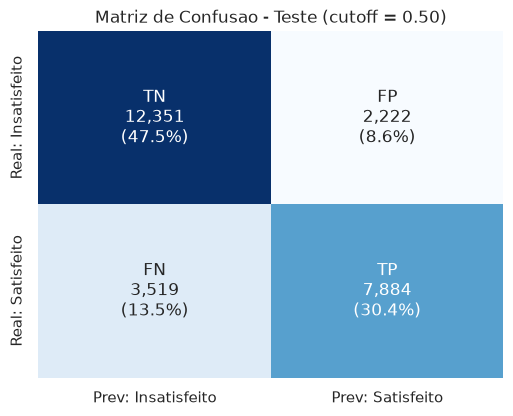

                     precision    recall  f1-score   support

Neutro/Insatisfeito      0.778     0.848     0.811     14573
         Satisfeito      0.780     0.691     0.733     11403

           accuracy                          0.779     25976
          macro avg      0.779     0.769     0.772     25976
       weighted avg      0.779     0.779     0.777     25976



In [14]:
def plot_matriz_confusao(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    pct = cm / cm.sum() * 100
    nomes = [["TN", "FP"], ["FN", "TP"]]
    labels = [[f"{nomes[i][j]}\n{cm[i, j]:,}\n({pct[i, j]:.1f}%)" for j in range(2)] for i in range(2)]
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(
        cm, annot=labels, fmt="", cmap="Blues", cbar=False,
        xticklabels=["Prev: Insatisfeito", "Prev: Satisfeito"],
        yticklabels=["Real: Insatisfeito", "Real: Satisfeito"],
    )
    plt.title(titulo)
    plt.show()


def metricas(y_true, y_pred):
    return {
        "Acuracia": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }


cutoff_padrao = 0.50
y_pred_padrao = (score_test >= cutoff_padrao).astype(int)

plot_matriz_confusao(y_test, y_pred_padrao, f"Matriz de Confusao - Teste (cutoff = {cutoff_padrao:.2f})")
print(classification_report(y_test, y_pred_padrao, target_names=["Neutro/Insatisfeito", "Satisfeito"], digits=3))

> Com cutoff 0,50 o modelo acerta ~78% dos casos e tem **precision alta (~0,78)**, mas **recall de apenas ~0,69**: cerca de 3.500 passageiros satisfeitos foram classificados como insatisfeitos (FN). O F1 da classe positiva fica em **~0,73**.

### 6.3 Escolha do ponto de corte

O cutoff 0,50 nao e obrigatorio: ele deve refletir o objetivo do negocio. Aqui buscamos o cutoff que **maximiza o F1**. Essa escolha e feita **na base de treino** (escolher olhando o teste seria outra forma de *leakage*) e depois aplicada ao teste.

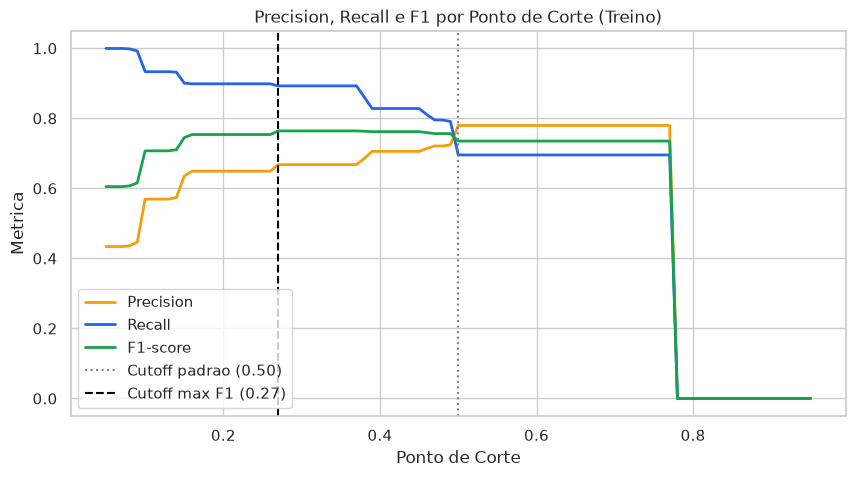

In [15]:
cutoffs = np.arange(0.05, 0.96, 0.01)
curva = pd.DataFrame(
    [{"Cutoff": c, **metricas(y_train, (score_train >= c).astype(int))} for c in cutoffs]
)
cutoff_otimo = curva.loc[curva["F1-score"].idxmax(), "Cutoff"]

plt.figure(figsize=(10, 5))
for col, cor in [("Precision", "#f59e0b"), ("Recall", "#2563eb"), ("F1-score", "#16a34a")]:
    plt.plot(curva["Cutoff"], curva[col], label=col, color=cor, linewidth=2)
plt.axvline(cutoff_padrao, color="gray", linestyle=":", label=f"Cutoff padrao ({cutoff_padrao:.2f})")
plt.axvline(cutoff_otimo, color="black", linestyle="--", label=f"Cutoff max F1 ({cutoff_otimo:.2f})")
plt.title("Precision, Recall e F1 por Ponto de Corte (Treino)")
plt.xlabel("Ponto de Corte")
plt.ylabel("Metrica")
plt.legend()
plt.show()

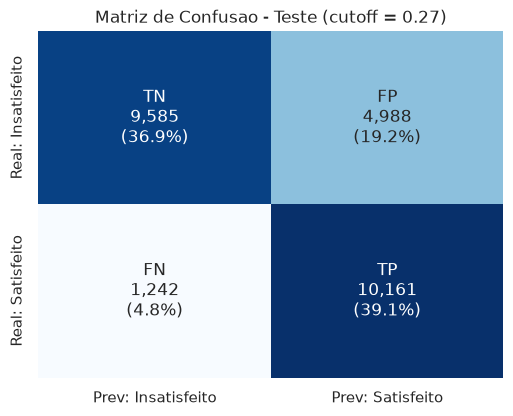

,Acuracia,Precision,Recall,F1-score
Cutoff 0.50,0.779,0.780,0.691,0.733
Cutoff 0.27,0.760,0.671,0.891,0.765


In [16]:
y_pred_otimo = (score_test >= cutoff_otimo).astype(int)
plot_matriz_confusao(y_test, y_pred_otimo, f"Matriz de Confusao - Teste (cutoff = {cutoff_otimo:.2f})")

pd.DataFrame({
    f"Cutoff {cutoff_padrao:.2f}": metricas(y_test, y_pred_padrao),
    f"Cutoff {cutoff_otimo:.2f}": metricas(y_test, y_pred_otimo),
}).T.round(3)

> Reduzindo o cutoff para ~0,27, o **recall sobe de ~0,69 para ~0,89** e o **F1 melhora (~0,73 para ~0,77)**, ao custo de mais falsos positivos (a precision cai para ~0,67 e a acuracia para ~0,76). Esse e o *trade-off* classico: nao existe cutoff "certo", e sim o mais adequado ao custo de cada tipo de erro.

### 6.4 Tabela de Decis: o score na pratica

Outra forma de usar o score, sem fixar um cutoff: ordenamos os passageiros do maior para o menor score e os dividimos em **10 grupos de mesmo tamanho** (decis). Um bom modelo concentra os satisfeitos nos primeiros decis.

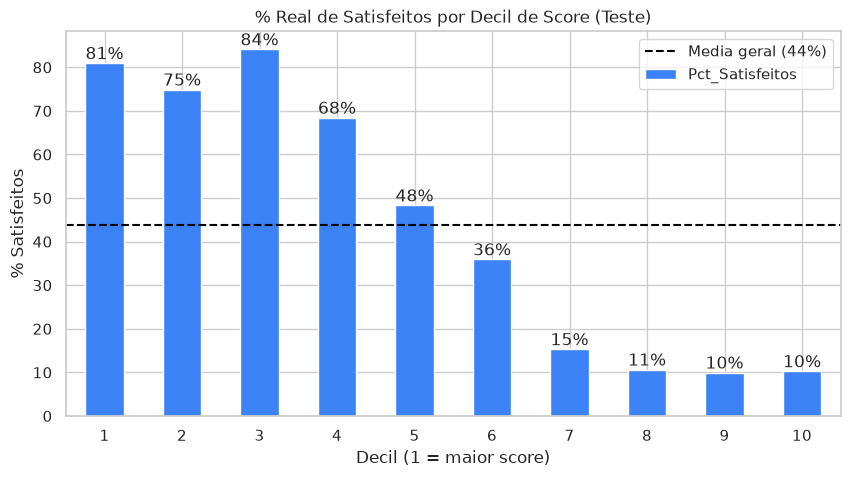

,Passageiros,Score_Min,Score_Max,Pct_Satisfeitos
Decil,,,,
1,2598,0.776,0.778,0.810
2,2598,0.773,0.776,0.749
3,2597,0.773,0.773,0.841
4,2598,0.496,0.773,0.684
5,2597,0.456,0.496,0.483
6,2598,0.261,0.456,0.360
7,2597,0.147,0.261,0.153
8,2598,0.093,0.147,0.107
9,2597,0.091,0.093,0.100


In [17]:
df_score = pd.DataFrame({"Score": score_test, "Real": y_test.values})
df_score["Decil"] = pd.qcut(df_score["Score"].rank(method="first", ascending=False), q=10, labels=range(1, 11))

tabela_decis = df_score.groupby("Decil", observed=True).agg(
    Passageiros=("Real", "size"),
    Score_Min=("Score", "min"),
    Score_Max=("Score", "max"),
    Pct_Satisfeitos=("Real", "mean"),
)

ax = (tabela_decis["Pct_Satisfeitos"] * 100).plot(kind="bar", color="#3b82f6", rot=0)
ax.bar_label(ax.containers[0], fmt="%.0f%%")
ax.axhline(y_test.mean() * 100, color="black", linestyle="--", label=f"Media geral ({y_test.mean():.0%})")
ax.set_title("% Real de Satisfeitos por Decil de Score (Teste)")
ax.set_xlabel("Decil (1 = maior score)")
ax.set_ylabel("% Satisfeitos")
ax.legend()
plt.show()

tabela_decis.round(3)

> Os **4 primeiros decis** tem entre ~68% e ~84% de satisfeitos, enquanto os **decis 7 a 10** ficam entre ~10% e ~15%. Com apenas variaveis de reserva, o modelo ja separa bem um grupo de **alto risco de insatisfacao**. A ordem nao e perfeitamente decrescente nos primeiros decis porque, com poucas variaveis (quase todas categoricas), muitos passageiros compartilham perfis e scores muito parecidos.

## 7. Conclusao

| Etapa | Principal aprendizado |
|---|---|
| **EDA** | `Type of Travel`, `Class` e `Customer Type` concentram o poder de separacao; `Age` e `Flight Distance` parecem relevantes isoladamente, mas estao confundidas com as anteriores. |
| **Modelo** | Viagem pessoal, classe economica e cliente nao fiel reduzem fortemente as chances de satisfacao ($OR$ entre ~0,10 e ~0,28). |
| **ROC / AUC** | AUC ~0,83 no teste, igual ao treino: boa discriminacao e sem overfitting. |
| **Matriz de Confusao / F1** | Com cutoff 0,50: F1 ~0,73. Ajustando o cutoff (escolhido no treino) para ~0,27: F1 ~0,77 e recall ~0,89. |

**Aplicacao de negocio**: antes do embarque, a companhia pode usar o score para priorizar acoes preventivas (comunicacao proativa, oferta de upgrade, beneficios) nos passageiros de menor score. O ponto de corte deve ser definido comparando o custo da acao preventiva com o custo de um cliente insatisfeito.

**Limitacao**: o modelo usa apenas 6 variaveis cadastrais. As notas de servico explicam muito melhor a satisfacao, mas so existem depois do voo, e por isso foram excluidas de proposito.